Sơ đồ Tổng quan Hệ thống (System Flowchart)

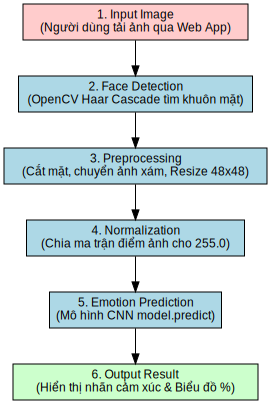

In [ ]:
import graphviz
from IPython.display import display

# Khởi tạo sơ đồ
dot = graphviz.Digraph(comment='Hệ thống Nhận diện Cảm xúc', format='png')
dot.attr(rankdir='TB', size='8,8')
dot.attr('node', shape='box', style='filled', fillcolor='lightblue', fontname='Arial', fontsize='12')

# Tạo các khối (Nodes) bám sát app.py
dot.node('A', '1. Input Image\n(Người dùng tải ảnh qua Web App)', fillcolor='#ffcccc')
dot.node('B', '2. Face Detection\n(OpenCV Haar Cascade tìm khuôn mặt)')
dot.node('C', '3. Preprocessing\n(Cắt mặt, chuyển ảnh xám, Resize 48x48)')
dot.node('D', '4. Normalization\n(Chia ma trận điểm ảnh cho 255.0)')
dot.node('E', '5. Emotion Prediction\n(Mô hình CNN model.predict)')
dot.node('F', '6. Output Result\n(Hiển thị nhãn cảm xúc & Biểu đồ %)', fillcolor='#ccffcc')

# Nối các khối lại với nhau (Edges)
dot.edges(['AB', 'BC', 'CD', 'DE', 'EF'])

# Hiển thị sơ đồ ngay trên Colab
display(dot)

Sơ đồ Luồng xử lý Dữ liệu (Data Pipeline)

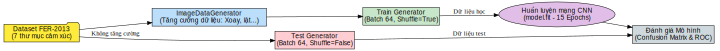

In [ ]:
import graphviz
from IPython.display import display

pipeline = graphviz.Digraph(comment='Luồng Dữ liệu FER-2013', format='png')
pipeline.attr(rankdir='LR', size='10,6') # Vẽ theo chiều ngang (Left to Right)
pipeline.attr('node', shape='box', style='filled', fillcolor='#f9f9f9', fontname='Arial')

# Các khối xử lý dữ liệu
pipeline.node('Data', 'Dataset FER-2013\n(7 thư mục cảm xúc)', shape='folder', fillcolor='#ffeb3b')
pipeline.node('Aug', 'ImageDataGenerator\n(Tăng cường dữ liệu: Xoay, lật...)', fillcolor='#bbdefb')
pipeline.node('TrainGen', 'Train Generator\n(Batch 64, Shuffle=True)', fillcolor='#c8e6c9')
pipeline.node('TestGen', 'Test Generator\n(Batch 64, Shuffle=False)', fillcolor='#ffcdd2')
pipeline.node('CNN', 'Huấn luyện mạng CNN\n(model.fit - 15 Epochs)', shape='ellipse', fillcolor='#e1bee7')
pipeline.node('Eval', 'Đánh giá Mô hình\n(Confusion Matrix & ROC)', fillcolor='#cfd8dc')

# Nối các khối
pipeline.edge('Data', 'Aug')
pipeline.edge('Aug', 'TrainGen')
pipeline.edge('Data', 'TestGen', label=' Không tăng cường')
pipeline.edge('TrainGen', 'CNN', label=' Dữ liệu học')
pipeline.edge('TestGen', 'Eval', label=' Dữ liệu test')
pipeline.edge('CNN', 'Eval')

# Hiển thị
display(pipeline)

Ma trận Nhầm lẫn

Found 7178 images belonging to 7 classes.

Đang tính toán... AI đang chấm điểm hàng ngàn bức ảnh, vui lòng đợi vài chục giây...
113/113 ━━━━━━━━━━━━━━━━━━━━ 11s 96ms/step


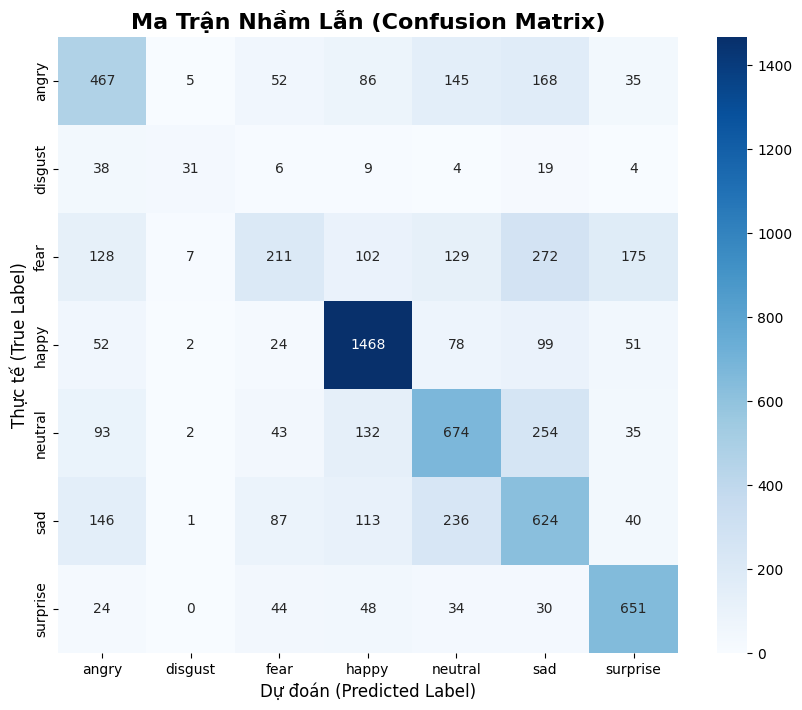


📊 BÁO CÁO ĐÁNH GIÁ CHI TIẾT (CLASSIFICATION REPORT)
              precision    recall  f1-score   support

       angry       0.49      0.49      0.49       958
     disgust       0.65      0.28      0.39       111
        fear       0.45      0.21      0.28      1024
       happy       0.75      0.83      0.79      1774
     neutral       0.52      0.55      0.53      1233
         sad       0.43      0.50      0.46      1247
    surprise       0.66      0.78      0.71       831

    accuracy                           0.57      7178
   macro avg       0.56      0.52      0.52      7178
weighted avg       0.56      0.57      0.56      7178



In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Load lại tập test (BẮT BUỘC để shuffle=False để không bị lộn xộn thứ tự ảnh)
test_generator_cm = datagen.flow_from_directory(
    test_dir,
    target_size=(48, 48),
    color_mode="grayscale",
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)

# 2. Cho AI làm bài thi (Dự đoán trên toàn bộ tập test)
print("\nĐang tính toán... AI đang chấm điểm hàng ngàn bức ảnh, vui lòng đợi vài chục giây...")
predictions = model.predict(test_generator_cm)

# 3. Lọc ra câu trả lời cuối cùng (Lấy cảm xúc có % cao nhất)
y_pred = np.argmax(predictions, axis=1)

# Lấy đáp án chuẩn từ thư mục
y_true = test_generator_cm.classes
class_names = list(test_generator_cm.class_indices.keys())

# 4. Tính toán Ma trận nhầm lẫn
cm = confusion_matrix(y_true, y_pred)

# 5. Vẽ biểu đồ Ma trận nhầm lẫn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Ma Trận Nhầm Lẫn (Confusion Matrix)', fontsize=16, fontweight='bold')
plt.ylabel('Thực tế (True Label)', fontsize=12)
plt.xlabel('Dự đoán (Predicted Label)', fontsize=12)
plt.show()

# 6. In Báo cáo phân loại chi tiết (Điểm F1-Score, Precision, Recall)
print("\n" + "="*50)
print("📊 BÁO CÁO ĐÁNH GIÁ CHI TIẾT (CLASSIFICATION REPORT)")
print("="*50)
print(classification_report(y_true, y_pred, target_names=class_names))

Sơ đồ Kiến trúc CNN Chính xác (Model Architecture)

✅ Đã vẽ sơ đồ kiến trúc CNN bám sát mô hình của bạn thành công!


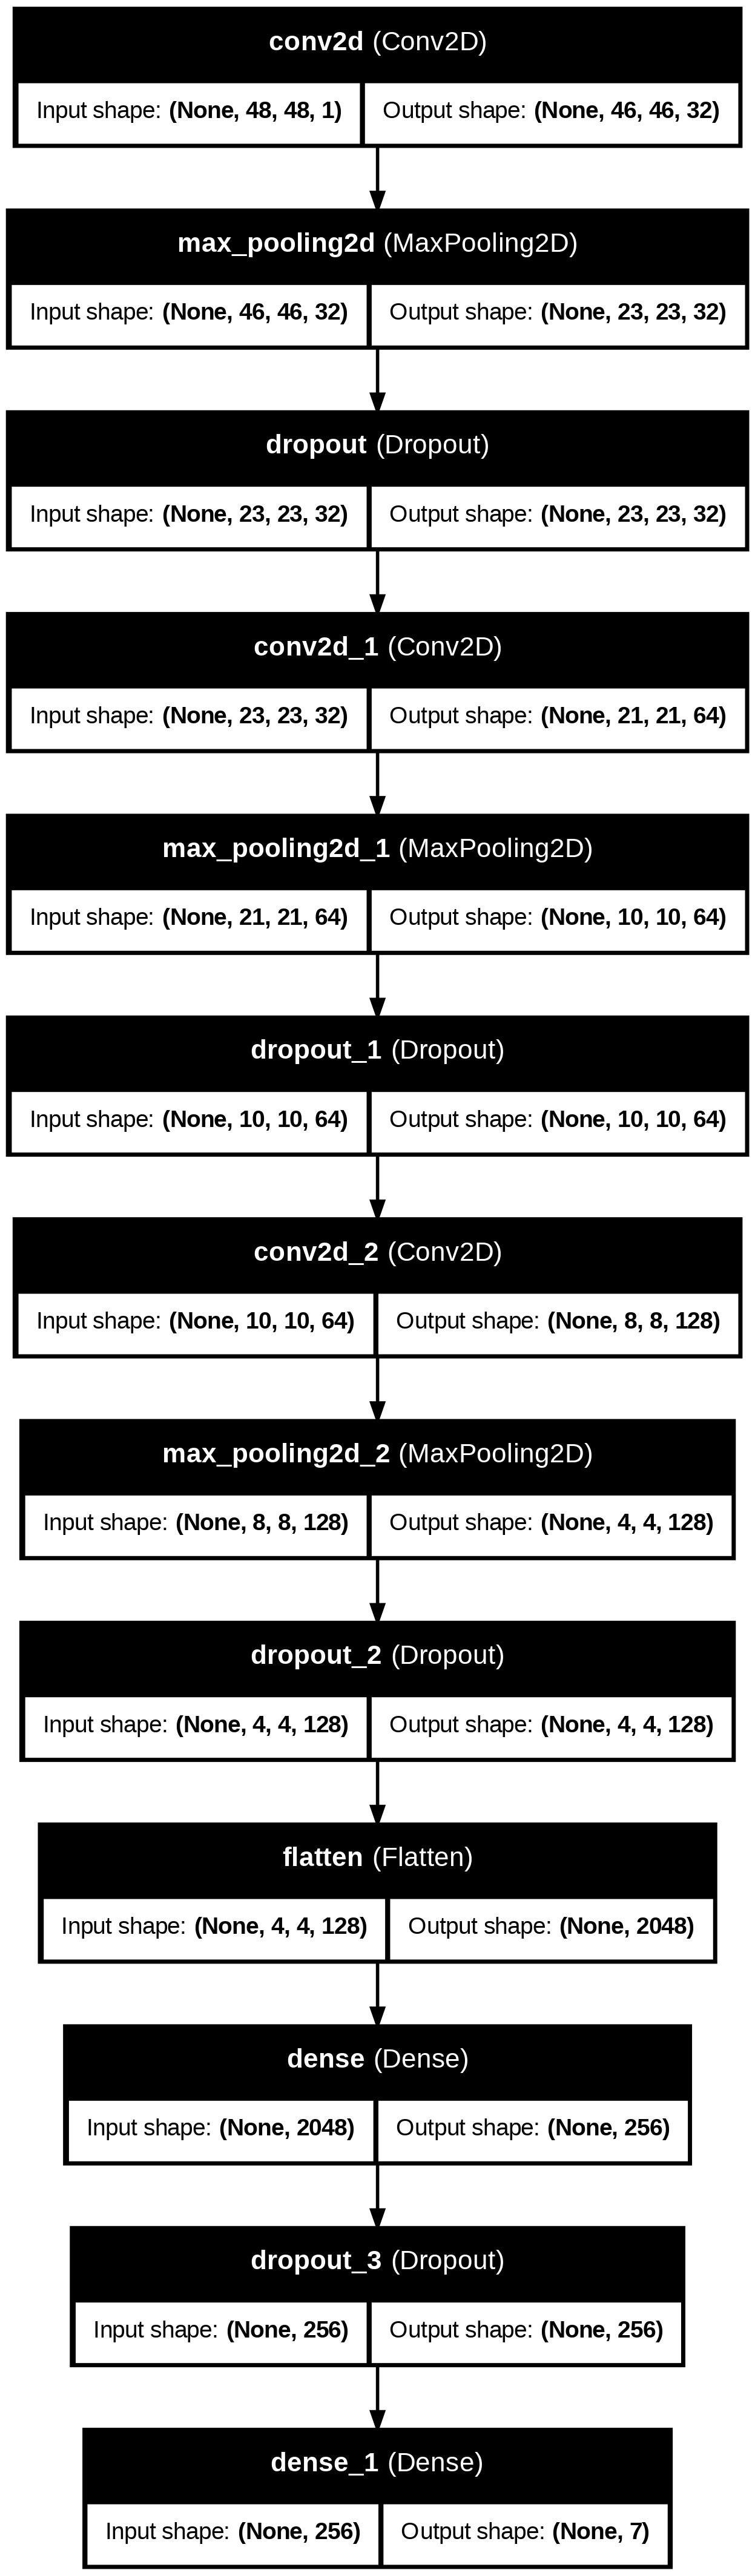

In [ ]:
from keras.utils import plot_model

# 1. Vẽ kiến trúc mô hình và lưu thành file 'model_architecture.png'
# show_shapes=True: Hiển thị kích thước dữ liệu (None, 48, 48, 1) -> RẤT QUAN TRỌNG
# show_layer_names=True: Hiển thị tên lớp (conv2d, dense...)
plot_model(model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True, rankdir='TB')

# 2. Hiển thị ảnh vừa vẽ ngay trên màn hình Colab
from IPython.display import Image
print("✅ Đã vẽ sơ đồ kiến trúc CNN bám sát mô hình của bạn thành công!")
Image(filename='model_architecture.png')

**Giải thích Sơ đồ Kiến trúc CNN**

  InputLayer (Lớp đầu vào): Nhận ảnh đầu vào đã qua tiền xử lý, kích thước 48x48
pixel, 1 kênh màu (ảnh xám).



  Conv2D (Lớp Tích chập): Đóng vai trò như các "bộ lọc" quét qua bức ảnh để tìm kiếm và trích xuất các đặc trưng khuôn mặt (đường nét, góc cạnh, độ cong của miệng...).



MaxPooling2D (Lớp Gộp tối đa): Giúp nén và giảm kích thước ma trận hình ảnh, giữ lại những đặc trưng nổi bật nhất, đồng thời giúp AI chạy nhẹ và nhanh hơn.



Dropout (Lớp Bỏ qua): Ngẫu nhiên "ngắt" một số nơ-ron trong quá trình học. Kỹ thuật này ép các nơ-ron còn lại phải học kỹ hơn, chống hiện tượng mô hình học vẹt (Overfitting).



Flatten (Lớp Trải phẳng): Biến ma trận hình ảnh 2D nhiều chiều thành một mảng 1D duy nhất để đưa vào bước suy luận cuối.



Dense (Lớp Kết nối đầy đủ): Đóng vai trò cốt lõi trong việc đưa ra quyết định. Lớp Dense cuối cùng (Output) sử dụng hàm Softmax để xuất ra 7 con số tương ứng với tỷ lệ % của 7 cảm xúc.


Tải bộ dữ liệu chuẩn FER-2013
, dùng bộ dữ liệu FER-2013 nổi tiếng nhất cho bài toán này (gồm các ảnh khuôn mặt đen trắng cỡ 48x48 pixel, chia làm 7 cảm xúc: Tức giận, Ghê tởm, Sợ hãi, Vui vẻ, Buồn bã, Bất ngờ, Bình thường).

In [1]:
# Cài đặt thư viện kaggle
!pip install -q kaggle

# Tải file kaggle.json của bạn lên Colab
from google.colab import files
files.upload() # Lúc này Colab sẽ hiện nút Browse, bạn chọn file kaggle.json nhé

# Phân quyền và tải bộ dữ liệu FER-2013 về
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d msambare/fer2013

# Giải nén dữ liệu
!unzip -q fer2013.zip -d dataset/
print("Đã tải và giải nén dữ liệu thành công!")

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
100% 60.3M/60.3M [00:00<00:00, 264MB/s]

Đã tải và giải nén dữ liệu thành công!


BƯỚC 2: Import thư viện và Tiền xử lý dữ liệu (Data Preprocessing)
Chúng ta sẽ khai báo các công cụ cần thiết và dùng ImageDataGenerator để tự động đưa ảnh vào mô hình.

In [17]:
import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Khai báo đường dẫn
train_dir = 'dataset/train'
test_dir = 'dataset/test'

# Chuẩn hóa dữ liệu (Đưa giá trị pixel từ 0-255 về 0-1 để máy dễ học)
datagen = ImageDataGenerator(rescale=1./255)

# Load dữ liệu huấn luyện
train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),
    color_mode="grayscale",
    batch_size=64,
    class_mode='categorical'
)

# Load dữ liệu kiểm thử
test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=(48, 48),
    color_mode="grayscale",
    batch_size=64,
    class_mode='categorical'
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


BƯỚC 3: Xây dựng cấu trúc Mạng nơ-ron Tích chập (CNN)

In [ ]:
# Khởi tạo mô hình
model = Sequential()

# Khối 1: Lớp tích chập đầu tiên tìm các đường nét cơ bản
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(48, 48, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25)) # Dropout giúp chống học vẹt (Overfitting)

# Khối 2: Tìm các đặc trưng phức tạp hơn
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Khối 3: Trích xuất đặc trưng sâu
model.add(Conv2D(128, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Duỗi phẳng ma trận ảnh thành mảng 1 chiều
model.add(Flatten())

# Lớp ẩn để tổng hợp thông tin
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

# Lớp đầu ra: 7 neurons tương ứng với 7 cảm xúc, dùng hàm softmax để tính xác suất %
model.add(Dense(7, activation='softmax'))

# Biên dịch mô hình
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary() # In ra cấu trúc để báo cáo

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 619,015 (2.36 MB)

 Trainable params: 619,015 (2.36 MB)

 Non-trainable params: 0 (0.00 B)

BƯỚC 4: Huấn luyện mô hình (Training) và Vẽ biểu đồ
Bây giờ chúng ta cho máy học. Tôi để epochs=15 (học 15 vòng) để thời gian chạy trên Colab chỉ tốn khoảng vài phút.

Epoch 1/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 111s 241ms/step - accuracy: 0.2787 - loss: 1.7636 - val_accuracy: 0.3908 - val_loss: 1.5992
Epoch 2/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 106s 236ms/step - accuracy: 0.4067 - loss: 1.5389 - val_accuracy: 0.4641 - val_loss: 1.3891
Epoch 3/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 105s 235ms/step - accuracy: 0.4543 - loss: 1.4203 - val_accuracy: 0.4961 - val_loss: 1.3035
Epoch 4/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 105s 234ms/step - accuracy: 0.4895 - loss: 1.3386 - val_accuracy: 0.5198 - val_loss: 1.2633
Epoch 5/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 105s 233ms/step - accuracy: 0.5055 - loss: 1.2927 - val_accuracy: 0.5281 - val_loss: 1.2167
Epoch 6/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 105s 233ms/step - accuracy: 0.5231 - loss: 1.2560 - val_accuracy: 0.5422 - val_loss: 1.1924
Epoch 7/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 105s 234ms/step - accuracy: 0.5310 - loss: 1.2301 - val_accuracy: 0.5446 - val_loss: 1.1793
Epoch 8/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 105s 235ms/step - accuracy: 0.5467 -

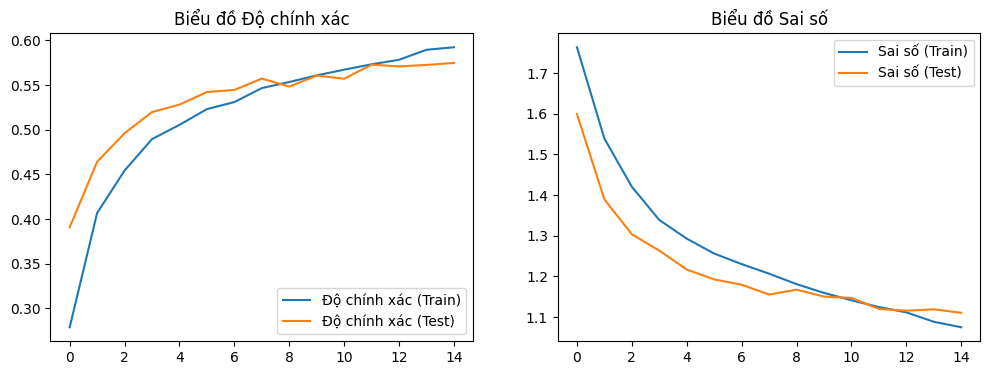

In [ ]:
# Bắt đầu huấn luyện
history = model.fit(
    train_generator,
    epochs=15,
    validation_data=test_generator
)

# Vẽ biểu đồ kết quả để dán vào Tiểu luận và Slide PPT
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Độ chính xác (Train)')
plt.plot(history.history['val_accuracy'], label='Độ chính xác (Test)')
plt.title('Biểu đồ Độ chính xác')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Sai số (Train)')
plt.plot(history.history['val_loss'], label='Sai số (Test)')
plt.title('Biểu đồ Sai số')
plt.legend()
plt.show()

# Lưu mô hình lại để sau này dùng mà không cần train lại
model.save("emotion_model.h5")

 Demo thực tế. Bạn hãy tải một bức ảnh mặt cười (hoặc mặt buồn) của bạn lên Colab (đặt tên là test_image.jpg), mô hình sẽ tự động đoán cảm xúc.

Vui lòng tải lên ảnh (có thể tải ảnh nguyên người, AI sẽ tự tìm mặt):


Saving images.jpg to images.jpg

✅ THÀNH CÔNG: Tìm thấy 1 khuôn mặt! Đang phân tích khuôn mặt đầu tiên...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step
🎯 KẾT QUẢ CẢM XÚC: VUI VẺ


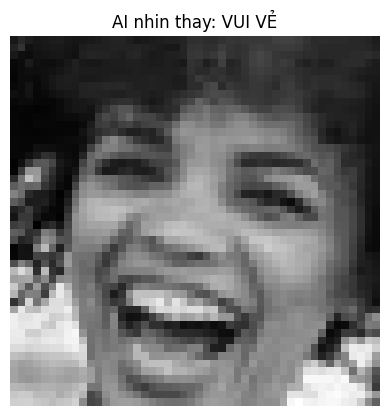

In [ ]:
import cv2
import numpy as np
from tensorflow.keras.preprocessing import image
from google.colab import files
import matplotlib.pyplot as plt

# 1. Tải công cụ dò tìm khuôn mặt tự động của OpenCV về Colab
!wget -q -O haarcascade_frontalface_default.xml https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')

emotion_labels = ['Tức giận', 'Ghê tởm', 'Sợ hãi', 'Vui vẻ', 'Bình thường', 'Buồn bã', 'Bất ngờ']

print("Vui lòng tải lên ảnh (có thể tải ảnh nguyên người, AI sẽ tự tìm mặt):")
uploaded = files.upload()

for file_name in uploaded.keys():
    # 2. Đọc ảnh và chuyển sang ảnh xám
    img_color = cv2.imread(file_name)
    gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

    # 3. AI bắt đầu quét tìm khuôn mặt trong ảnh
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)

    if len(faces) == 0:
        print("\n❌ TRỜI ƠI! OpenCV không tìm thấy khuôn mặt nào trong ảnh này! Hãy thử ảnh chụp thẳng mặt rõ hơn nhé.")
    else:
        print(f"\n✅ THÀNH CÔNG: Tìm thấy {len(faces)} khuôn mặt! Đang phân tích khuôn mặt đầu tiên...")
        for (x, y, w, h) in faces:
            # 4. Tự động cắt đúng khuôn mặt ra
            face_roi = gray[y:y+h, x:x+w]
            face_resized = cv2.resize(face_roi, (48, 48))

            # 5. Tiền xử lý và đưa vào mô hình dự đoán
            img_array = image.img_to_array(face_resized)
            img_array = np.expand_dims(img_array, axis=0) / 255.0

            predictions = model.predict(img_array)
            max_index = np.argmax(predictions[0])
            predicted_emotion = emotion_labels[max_index]

            print(f"==========================================")
            print(f"🎯 KẾT QUẢ CẢM XÚC: {predicted_emotion.upper()}")
            print(f"==========================================")

            # 6. In luôn cái mặt đã cắt ra màn hình cho bạn xem AI nó phân tích cái gì
            plt.imshow(face_resized, cmap='gray')
            plt.title(f"AI nhin thay: {predicted_emotion.upper()}")
            plt.axis('off')
            plt.show()
            break # Chỉ xử lý 1 khuôn mặt đầu tiên tìm thấy

In [20]:
from tensorflow.keras.models import load_model

# không cần train lại bước 3&4
model = load_model('emotion_model_v2.h5')
print("Đã load mô hình thành công, sẵn sàng dự đoán!")

Đã load mô hình thành công, sẵn sàng dự đoán!


GIAO DIỆN WEB (TÍCH HỢP CSV)

In [9]:
%%writefile app.py
import streamlit as st
import cv2
import numpy as np
from tensorflow.keras.models import load_model
from PIL import Image
import pandas as pd
import os
import csv
from datetime import datetime

# =====================================================================
# ⚙️ CẤU HÌNH HỆ THỐNG
# =====================================================================
MODEL_FILENAME = 'emotion_model_v2.h5'

def luu_lich_su(ten_file, ai_doan, nguoi_dung_sua):
    file_path = 'lich_su_AI.csv'
    file_exists = os.path.isfile(file_path)
    with open(file_path, mode='a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        if not file_exists:
            writer.writerow(['Thời gian', 'Tên File Ảnh', 'AI Dự Đoán', 'Thực Tế (Feedback)'])
        thoi_gian = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        writer.writerow([thoi_gian, ten_file, ai_doan, nguoi_dung_sua])

def doc_lich_su():
    file_path = 'lich_su_AI.csv'
    if os.path.isfile(file_path):
        df = pd.read_csv(file_path)
        df['Thời gian'] = pd.to_datetime(df['Thời gian'])
        df = df.sort_values(by='Thời gian', ascending=False)
        return df
    return None

# =====================================================================
# --- CẤU HÌNH GIAO DIỆN CHUẨN ---
# =====================================================================
st.set_page_config(page_title="Hệ Thống Phân Tích Cảm Xúc 2.0", page_icon="🎭", layout="wide")

st.markdown("""
    <style>
    .stButton>button { width: 100%; background-color: #ff4b4b; color: white; font-weight: bold; border-radius: 10px; }
    h1, h2, h3 { font-family: 'Helvetica Neue', sans-serif; }
    .big-font { font-size: 2.5rem; font-weight: 800; color: #ff4b4b; text-align: center; }
    .stDataFrame { border: 1px solid #e6e6e6; border-radius: 10px; }
    </style>
""", unsafe_allow_html=True)

if 'analyzed' not in st.session_state:
    st.session_state.analyzed = False
if 'predictions' not in st.session_state:
    st.session_state.predictions = None
if 'face_roi' not in st.session_state:
    st.session_state.face_roi = None
if 'filename' not in st.session_state:
    st.session_state.filename = None

# =====================================================================
# --- SIDEBAR & LOAD MÔ HÌNH ---
# =====================================================================
with st.sidebar:
    st.image("https://cdn-icons-png.flaticon.com/512/3593/3593663.png", width=100)
    st.title("Thông Tin Đồ Án")
    st.info("Chuyên đề chuyên sâu phát triển phần mềm 2")
    st.success("SV: Triệu Duy Khang")
    st.write("Phiên bản: Cloud Pro 2.0 (MLOps Khép Kín)")
    st.markdown("---")
    st.write("### ⚙️ Điều khiển")
    refresh_hist = st.button("🔄 Làm mới Lịch sử")

@st.cache_resource
def load_essentials():
    model = load_model(MODEL_FILENAME)
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    return model, face_cascade

try:
    model, face_cascade = load_essentials()
except Exception as e:
    st.error(f"😭 LỖI: Chưa thấy file '{MODEL_FILENAME}' trong thư mục. Khang kiểm tra lại tên file nhé!")
    st.stop()

emotion_labels = ['Tức giận 😠', 'Ghê tởm 🤢', 'Sợ hãi 😨', 'Vui vẻ 😊', 'Bình thường 😐', 'Buồn bã 😢', 'Bất ngờ 😮']
emotion_labels_raw = ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']

# =====================================================================
# --- BỐ CỤC CHÍNH ---
# =====================================================================
st.write("# 🎭 Hệ Thống Phân Tích Cảm Xúc Pro 2.0")
st.markdown("---")

col_input, col_result = st.columns([1, 1.2])

with col_input:
    st.subheader("📸 Bước 1: Tải ảnh của bạn")
    uploaded_file = st.file_uploader("Chọn ảnh...", type=["jpg", "jpeg", "png"], key="file_uploader")

    analyze_btn = False
    if uploaded_file is not None:
        image = Image.open(uploaded_file)
        st.image(image, use_column_width=True)
        analyze_btn = st.button("🚀 BẮT ĐẦU PHÂN TÍCH")
    else:
        st.session_state.analyzed = False
        st.session_state.predictions = None
        st.session_state.filename = None

# =====================================================================
# --- XỬ LÝ AI ---
# =====================================================================
if uploaded_file is not None and analyze_btn:
    with st.spinner('AI đang suy nghĩ...'):
        img_array = np.array(image.convert('RGB'))
        img_bgr = cv2.cvtColor(img_array, cv2.COLOR_RGB2BGR)
        gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

        faces = face_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)

        if len(faces) == 0:
            st.error("😭 Không tìm thấy khuôn mặt nào!")
            st.session_state.analyzed = False
        else:
            (x, y, w, h) = faces[0]
            face_roi = gray[y:y+h, x:x+w]
            face_roi_resized = cv2.resize(face_roi, (48, 48))

            face_input = np.expand_dims(face_roi_resized, axis=-1)
            face_input = np.expand_dims(face_input, axis=0) / 255.0

            predictions = model.predict(face_input)[0]

            st.session_state.analyzed = True
            st.session_state.predictions = predictions
            st.session_state.face_roi = face_roi_resized
            st.session_state.filename = uploaded_file.name

# =====================================================================
# --- HIỂN THỊ KẾT QUẢ & BIỂU ĐỒ ---
# =====================================================================
with col_result:
    st.subheader("📊 Bước 2: Kết quả từ AI")

    if st.session_state.analyzed and uploaded_file is not None:
        predictions = st.session_state.predictions
        face_roi = st.session_state.face_roi

        max_index = int(np.argmax(predictions))
        predicted_emotion = emotion_labels[max_index]
        predicted_emotion_raw = emotion_labels_raw[max_index]

        sub_col1, sub_col2 = st.columns([1, 2])
        with sub_col1:
            st.image(face_roi, caption="Mặt AI nhìn thấy", width=150, clamp=True)
        with sub_col2:
            st.markdown(f"<div class='big-font'>{predicted_emotion.upper()}</div>", unsafe_allow_html=True)

        st.markdown("---")

        st.write("### 📈 Phân bổ Xác suất % Chi tiết")
        prob_df = pd.DataFrame({
            'Cảm xúc': emotion_labels,
            'Xác suất (%)': predictions * 100
        }).sort_values(by='Xác suất (%)', ascending=True)
        st.bar_chart(prob_df, x='Cảm xúc', y='Xác suất (%)', use_container_width=True)

        st.markdown("---")

        # 🧠 TÍNH NĂNG MLOPS: THU THẬP FEEDBACK & LƯU ẢNH
        st.write("### 🧠 Góp ý để AI thông minh hơn")
        st.info("Hệ thống sẽ ghi nhận phản hồi vào file CSV và lưu lại ảnh lỗi.")
        with st.form("feedback_form", clear_on_submit=False):
            correct_emotion = st.selectbox("Cảm xúc thực sự của bức ảnh này là gì?", options=emotion_labels, index=max_index)
            submit_feedback = st.form_submit_button("Lưu dữ liệu Feedback")

            if submit_feedback:
                # 1. Lưu CSV
                luu_lich_su(st.session_state.filename, predicted_emotion, correct_emotion)

                # 2. Lưu Hình Ảnh
                if not os.path.exists("feedback_images"):
                    os.makedirs("feedback_images")
                cv2.imwrite(f"feedback_images/{st.session_state.filename}", st.session_state.face_roi)

                # 3. Thông báo
                st.success(f"✅ Đã lưu: AI đoán '{predicted_emotion}' | Thực tế '{correct_emotion}'. Dữ liệu đã sẵn sàng để Retrain AI.")

        st.markdown("---")
        st.write("### 🔄 Điều khiển")
        if st.button("Phân Tích Ảnh Khác"):
            st.session_state.analyzed = False
            st.session_state.predictions = None
            st.session_state.face_roi = None
            st.session_state.filename = None
            st.warning("⚠️ Vui lòng bấm dấu 'X' xóa ảnh cũ bên trái để tải ảnh mới lên nhé.")
            st.experimental_rerun()

# =====================================================================
# --- BẢNG LỊCH SỬ DƯỚI CÙNG ---
# =====================================================================
st.markdown("---")
st.write("## 📜 Lịch sử Phân tích & Góp ý của Người dùng")

df_history = doc_lich_su()

if df_history is not None:
    st.info(f"Hệ thống thu thập được {len(df_history)} mẫu dữ liệu góp ý. Dưới đây là các mẫu gần nhất:")
    st.dataframe(
        df_history.head(10),
        use_container_width=True,
        column_config={
            "Thời gian": st.column_config.DatetimeColumn(format="HH:mm:ss DD/MM/YYYY"),
            "AI Dự Đoán": st.column_config.TextColumn(width="medium"),
            "Thực Tế (Feedback)": st.column_config.TextColumn(width="medium")
        }
    )

    csv_data = df_history.to_csv(index=False).encode('utf-8')
    st.download_button(
        label="📥 Tải Cơ sở dữ liệu Feedback (CSV) về máy",
        data=csv_data,
        file_name='dataset_feedback_cam_xuc.csv',
        mime='text/csv',
    )
else:
    st.warning("Hệ thống chưa có dữ liệu lịch sử góp ý. Hãy thử dự đoán và gửi Feedback nhé!")

Overwriting app.py


KHỞI CHẠY MÁY CHỦ WEB

In [10]:
import time
import urllib.request
import json
import os

# ==========================================================
# BƯỚC 0: CÀI LẠI STREAMLIT (Cái mà mình vừa quên béng mất)
# ==========================================================
print("📦 0. Đang cài lại Streamlit và các thư viện (Đợi xíu nhé)...")
!pip install -q streamlit opencv-python-headless pandas

# ==========================================================
# BƯỚC 1: CÀI ĐẶT NGROK
# ==========================================================
print("⚙️ 1. Đang cài đặt Ngrok vào máy ảo...")
!curl -s https://ngrok-agent.s3.amazonaws.com/ngrok.asc | sudo tee /etc/apt/trusted.gpg.d/ngrok.asc >/dev/null
!echo "deb https://ngrok-agent.s3.amazonaws.com buster main" | sudo tee /etc/apt/sources.list.d/ngrok.list
!sudo apt update -y > /dev/null 2>&1
!sudo apt install ngrok -y > /dev/null 2>&1

# ==========================================================
# BƯỚC 2: DỌN DẸP & KÍCH HOẠT TOKEN
# ==========================================================
print("🧹 2. Dọn dẹp máy chủ và kích hoạt Token...")
!pkill -f streamlit
!pkill -f ngrok
!ngrok config add-authtoken DÁN TOKEN NGROK VÀO ĐÂY > /dev/null 2>&1

# ==========================================================
# BƯỚC 3: KHỞI CHẠY WEB & LẤY LINK
# ==========================================================
print("⏳ 3. Đang khởi động Web Streamlit ngầm...")
get_ipython().system_raw('streamlit run app.py --server.enableCORS false --server.enableXsrfProtection false &>/content/logs.txt &')
time.sleep(8) # Cho nó thêm vài giây để khởi động mượt mà

print("⏳ 4. Đang mở cổng mạng Ngrok...")
get_ipython().system_raw('ngrok http 8501 &>/dev/null &')
time.sleep(6)

try:
    req = urllib.request.urlopen('http://localhost:4040/api/tunnels')
    res = json.loads(req.read())
    public_url = res['tunnels'][0]['public_url']
    print("\n" + "="*70)
    print(f"🚀 THÀNH CÔNG! LINK WEB PRO 2.0 CỦA BẠN ĐÂY: {public_url}")
    print("="*70)
except Exception as e:
    print(f"\n😭 Lỗi chưa lấy được link: {e}")

📦 0. Đang cài lại Streamlit và các thư viện (Đợi xíu nhé)...
⚙️ 1. Đang cài đặt Ngrok vào máy ảo...
deb https://ngrok-agent.s3.amazonaws.com buster main
🧹 2. Dọn dẹp máy chủ và kích hoạt Token...
⏳ 3. Đang khởi động Web Streamlit ngầm...
⏳ 4. Đang mở cổng mạng Ngrok...

🚀 THÀNH CÔNG! LINK WEB PRO 2.0 CỦA BẠN ĐÂY: https://palaeanthropic-emptily-jefferey.ngrok-free.dev


Biểu đồ Phân bố Dữ liệu và Lưới Phân tích Lỗi Sai

🔄 Hệ thống vừa bị reset. Đang tự động nạp lại dữ liệu y_true và y_pred...
⏳ Đang dự đoán lại tập Test, chờ vài chục giây nhé...
113/113 ━━━━━━━━━━━━━━━━━━━━ 18s 156ms/step
✅ Đã nạp xong! Bắt đầu vẽ biểu đồ...



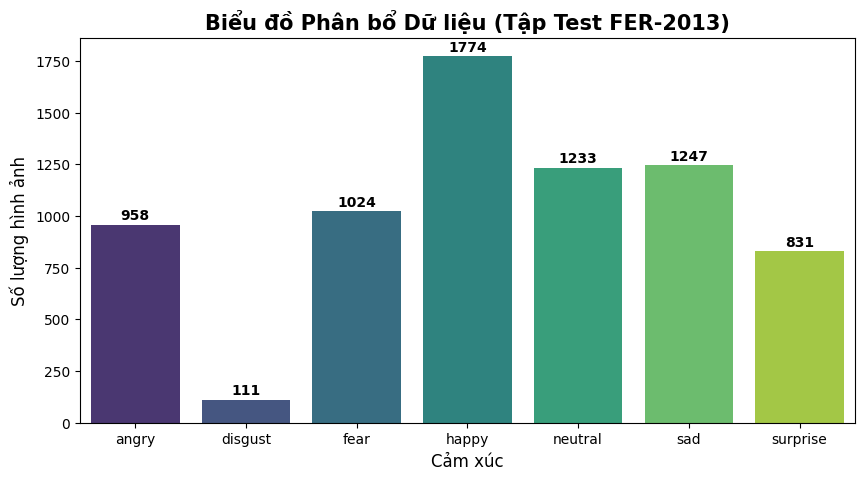


🧐 TÌM THẤY 3052 TRƯỜNG HỢP AI ĐOÁN NHẦM. ĐANG TRÍCH XUẤT MẪU...


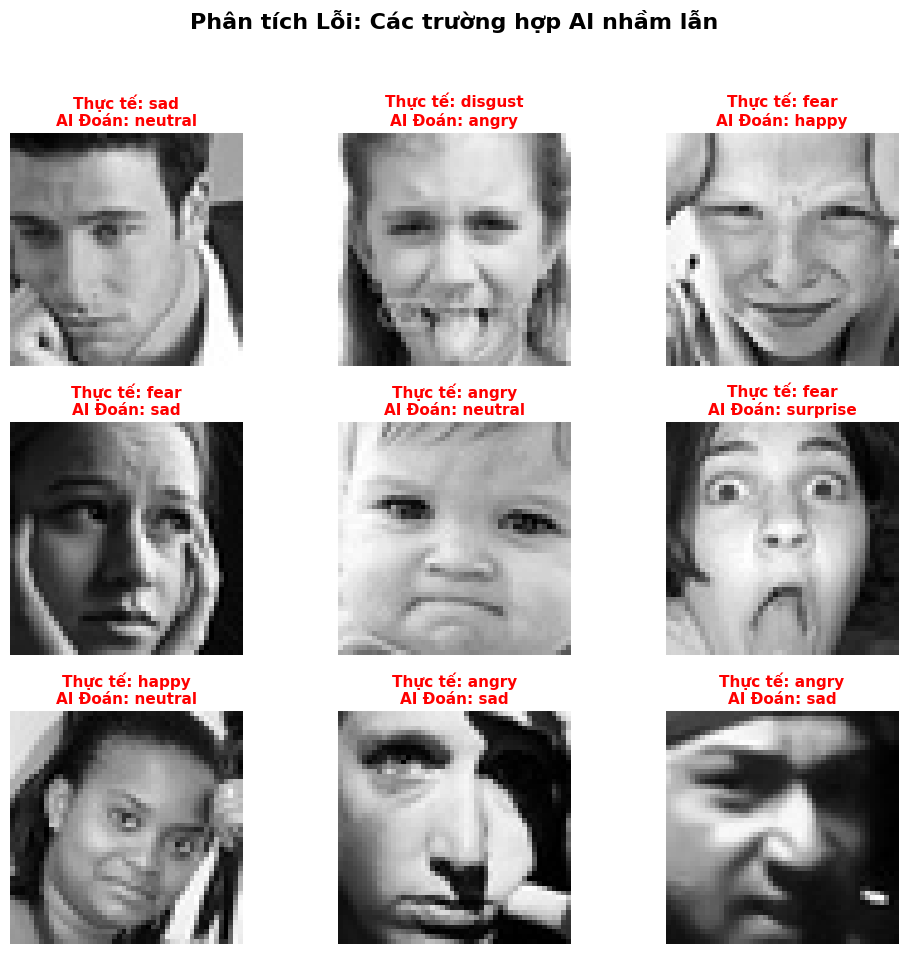

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os

if 'y_true' not in locals() or 'y_pred' not in locals():
    print("🔄 Hệ thống vừa bị reset. Đang tự động nạp lại dữ liệu y_true và y_pred...")
    try:
        # Lấy y_true từ generator
        y_true = test_generator_eval.classes
        class_names = list(test_generator_eval.class_indices.keys())

        # Cho model dự đoán lại để lấy y_pred
        print("⏳ Đang dự đoán lại tập Test, chờ vài chục giây nhé...")
        test_generator_eval.reset()
        y_pred = np.argmax(model.predict(test_generator_eval), axis=1)
        print("✅ Đã nạp xong! Bắt đầu vẽ biểu đồ...\n")
    except NameError as e:
        print(f"😭 LỖI THIẾU BIẾN CƠ BẢN: {e}")
        print("👉 CÁCH SỬA: Khang phải cuộn lên trên, bấm chạy cái ô load thư viện, load model và ô 'test_generator_eval = ...' trước nhé!")
        raise e # Dừng code lại ở đây

# =====================================================================
# BIỂU ĐỒ 1: PHÂN BỐ DỮ LIỆU (CLASS DISTRIBUTION)
# =====================================================================
unique_classes, class_counts = np.unique(y_true, return_counts=True)

plt.figure(figsize=(10, 5))
sns.barplot(x=class_names, y=class_counts, hue=class_names, palette="viridis", legend=False)
plt.title('Biểu đồ Phân bổ Dữ liệu (Tập Test FER-2013)', fontsize=15, fontweight='bold')
plt.xlabel('Cảm xúc', fontsize=12)
plt.ylabel('Số lượng hình ảnh', fontsize=12)

for i, count in enumerate(class_counts):
    plt.text(i, count + 10, str(count), ha='center', va='bottom', fontweight='bold')
plt.show()

# =====================================================================
# BIỂU ĐỒ 2: LƯỚI PHÂN TÍCH LỖI SAI (ERROR ANALYSIS)
# =====================================================================
incorrect_indices = np.where(y_pred != y_true)[0]

print("\n" + "="*60)
print(f"🧐 TÌM THẤY {len(incorrect_indices)} TRƯỜNG HỢP AI ĐOÁN NHẦM. ĐANG TRÍCH XUẤT MẪU...")
print("="*60)

if len(incorrect_indices) >= 9:
    random_incorrects = np.random.choice(incorrect_indices, 9, replace=False)

    plt.figure(figsize=(10, 10))
    plt.suptitle('Phân tích Lỗi: Các trường hợp AI nhầm lẫn', fontsize=16, fontweight='bold')

    # Gom ảnh từ generator
    test_generator_eval.reset()
    all_images = []
    for i in range(len(test_generator_eval)):
        x_batch, _ = next(test_generator_eval)
        all_images.extend(x_batch)
    all_images = np.array(all_images)

    for i, idx in enumerate(random_incorrects):
        plt.subplot(3, 3, i + 1)

        img = all_images[idx].squeeze()
        plt.imshow(img, cmap='gray')
        plt.axis('off')

        true_label = class_names[y_true[idx]]
        pred_label = class_names[y_pred[idx]]
        plt.title(f"Thực tế: {true_label}\nAI Đoán: {pred_label}", color='red', fontsize=11, fontweight='bold')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
else:
    print("Mô hình quá xịn, không tìm đủ 9 ảnh sai để hiển thị!")

Sơ đồ Luồng Vận hành MLOps (Data Collection Pipeline)

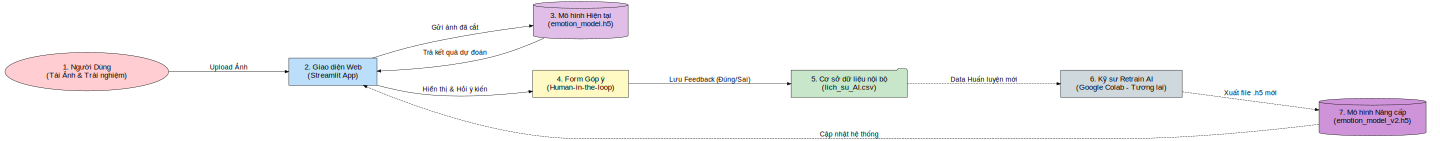

✅ Sơ đồ Luồng vận hành hệ thống đã được vẽ lại với kích thước lớn hơn!


In [ ]:
import graphviz
from IPython.display import Image, display

# 1. Khởi tạo sơ đồ luồng với cài đặt kích thước lớn hơn
# Tôi tăng size tổng thể và tăng font size tổng quát của sơ đồ
mlops_v2 = graphviz.Digraph(comment='Quy trình Thu thập dữ liệu và Cải tiến AI', format='png')
mlops_v2.attr(rankdir='LR', size='20,12', fontname='Arial', fontsize='22')

# 2. Cài đặt thuộc tính nút chung (Tăng kích thước phông chữ và lề của nút)
mlops_v2.attr('node', shape='box', style='filled', fontname='Arial', fontsize='20', margin='0.5,0.2')

# 3. Định nghĩa các khối chức năng (Nodes)
# Tăng margin trong node.attr giúp các khối lớn hơn một chút
mlops_v2.node('User', '1. Người Dùng\n(Tải Ảnh & Trải nghiệm)', fillcolor='#ffcdd2', shape='ellipse')
mlops_v2.node('App', '2. Giao diện Web\n(Streamlit App)', fillcolor='#bbdefb')
mlops_v2.node('Model_v1', '3. Mô hình Hiện tại\n(emotion_model.h5)', fillcolor='#e1bee7', shape='cylinder')
mlops_v2.node('Feedback', '4. Form Góp ý\n(Human-in-the-loop)', fillcolor='#fff9c4')
mlops_v2.node('CSV', '5. Cơ sở dữ liệu nội bộ\n(lich_su_AI.csv)', fillcolor='#c8e6c9', shape='folder')
mlops_v2.node('Retrain', '6. Kỹ sư Retrain AI\n(Google Colab - Tương lai)', fillcolor='#cfd8dc')
mlops_v2.node('Model_v2', '7. Mô hình Nâng cấp\n(emotion_model_v2.h5)', fillcolor='#ce93d8', shape='cylinder')

# 4. Cài đặt thuộc tính cạnh chung (Tăng kích thước phông chữ nhãn cạnh)
mlops_v2.attr('edge', fontname='Arial', fontsize='18')

# 5. Tăng khoảng cách để sơ đồ trải rộng hơn
# ranksep: khoảng cách giữa các tầng (ranks), ví dụ từ User -> App
# nodesep: khoảng cách giữa các nút trong một tầng (mặc dù ở đây hầu hết là một tầng một nút)
mlops_v2.attr(ranksep='3.0') # Khoảng cách giữa các tầng (Ví dụ từ User sang App)
mlops_v2.attr(nodesep='1.0') # Khoảng cách giữa các nút trong một tầng (ở đây chủ yếu theo chiều ngang)

# 6. Vẽ mũi tên luồng đi của dữ liệu (Edges)
mlops_v2.edge('User', 'App', label=' Upload Ảnh')
mlops_v2.edge('App', 'Model_v1', label=' Gửi ảnh đã cắt')
mlops_v2.edge('Model_v1', 'App', label=' Trả kết quả dự đoán')
mlops_v2.edge('App', 'Feedback', label=' Hiển thị & Hỏi ý kiến')
mlops_v2.edge('Feedback', 'CSV', label=' Lưu Feedback (Đúng/Sai)')
mlops_v2.edge('CSV', 'Retrain', label=' Data Huấn luyện mới', style='dashed')
mlops_v2.edge('Retrain', 'Model_v2', label=' Xuất file .h5 mới', style='dashed')
mlops_v2.edge('Model_v2', 'App', label=' Cập nhật hệ thống', style='dashed')

# 7. Hiển thị sơ đồ
# Sơ đồ sẽ hiển thị lớn hơn và rõ ràng hơn do các cài đặt phông chữ và khoảng cách đã tăng.
display(mlops_v2)

# Bạn cũng có thể tải hình ảnh xuống bằng cách click chuột phải vào sơ đồ và chọn 'Lưu hình ảnh thành...'
print("✅ Sơ đồ Luồng vận hành hệ thống đã được vẽ lại với kích thước lớn hơn!")

Biểu đồ Thống kê Chất lượng từ file CSV

📊 Đang phân tích 3 lượt phản hồi từ người dùng...


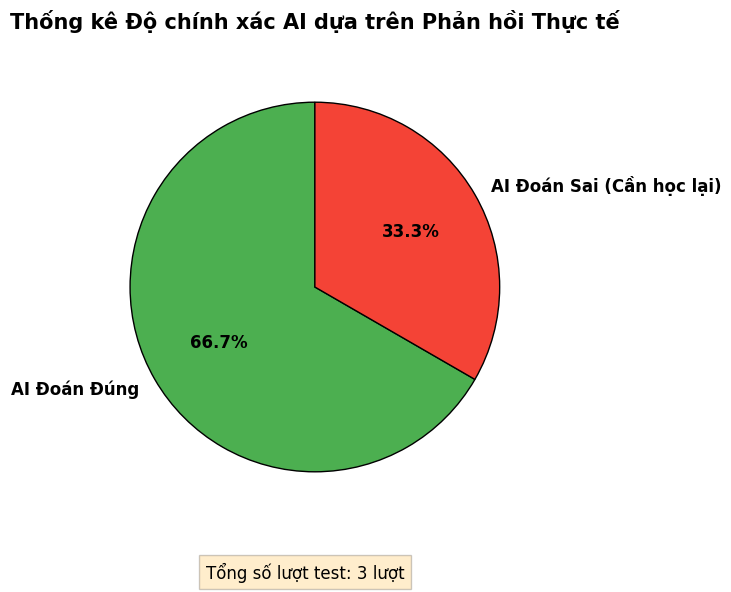

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

file_path = 'lich_su_AI.csv'

# Kiểm tra xem file CSV đã tồn tại và có dữ liệu chưa
if not os.path.exists(file_path):
    print("⚠️ Chưa tìm thấy file 'lich_su_AI.csv'. Bạn hãy vào Web App, tải ảnh và bấm 'Lưu dữ liệu Feedback' vài lần để tạo data nhé!")
else:
    try:
        # Đọc dữ liệu
        df = pd.read_csv(file_path)

        if len(df) == 0:
            print("⚠️ File CSV trống rỗng. Hãy test app thêm nhé.")
        else:
            print(f"📊 Đang phân tích {len(df)} lượt phản hồi từ người dùng...")

            # So sánh cột AI Dự đoán và Thực tế (Feedback)
            # Khởi tạo cột mới 'Đánh giá'
            df['Đánh giá'] = 'Khác'
            df.loc[df['AI Dự Đoán'] == df['Thực Tế (Feedback)'], 'Đánh giá'] = 'AI Đoán Đúng'
            df.loc[df['AI Dự Đoán'] != df['Thực Tế (Feedback)'], 'Đánh giá'] = 'AI Đoán Sai (Cần học lại)'

            # Đếm số lượng
            thong_ke = df['Đánh giá'].value_counts()

            # Vẽ Biểu đồ tròn
            plt.figure(figsize=(8, 6))
            colors = ['#4CAF50', '#F44336'] # Xanh lá (Đúng), Đỏ (Sai)

            plt.pie(thong_ke, labels=thong_ke.index, autopct='%1.1f%%',
                    startangle=90, colors=colors, wedgeprops={'edgecolor': 'black'},
                    textprops={'fontsize': 12, 'fontweight': 'bold'})

            plt.title('Thống kê Độ chính xác AI dựa trên Phản hồi Thực tế', fontsize=15, fontweight='bold', pad=20)

            # Hiển thị thêm một bảng tóm tắt nhỏ
            plt.figtext(0.5, 0.01, f"Tổng số lượt test: {len(df)} lượt", ha="center", fontsize=12, bbox={"facecolor":"orange", "alpha":0.2, "pad":5})

            plt.show()

    except Exception as e:
        print(f"Có lỗi khi đọc file: {e}")

Retrain

In [7]:
import pandas as pd
import numpy as np
import cv2
import os
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

print("🚀 KHỞI ĐỘNG QUY TRÌNH RETRAIN (HỌC CHUYỂN GIAO) TỪ FEEDBACK MLOPS...")

# 1. Đường dẫn tới file CSV và thư mục ảnh (Bạn tải từ máy tính lên Colab)
csv_path = 'lich_su_AI.csv'
img_folder = 'feedback_images/'

if not os.path.exists(csv_path) or not os.path.exists(img_folder):
    print("⚠️ Thiếu file lich_su_AI.csv hoặc thư mục feedback_images/. Hãy nạp dữ liệu lên Colab!")
else:
    df = pd.read_csv(csv_path)

    # Lọc lấy NHỮNG CA AI ĐOÁN SAI để tập trung học lại
    df_sai = df[df['AI Dự Đoán'] != df['Thực Tế (Feedback)']]

    if len(df_sai) == 0:
        print("✅ Mô hình đang hoạt động tốt, chưa có ca nào đoán sai để học lại!")
    else:
        print(f"📊 Tìm thấy {len(df_sai)} ca đoán sai từ người dùng. Đang nạp ảnh...")

        # Từ điển Map nhãn tiếng Việt sang số (0-6) giống với file Train gốc
        label_map = {'Tức giận 😠': 0, 'Ghê tởm 🤢': 1, 'Sợ hãi 😨': 2, 'Vui vẻ 😊': 3, 'Bình thường 😐': 4, 'Buồn bã 😢': 5, 'Bất ngờ 😮': 6}

        X_retrain = []
        Y_retrain = []

        for index, row in df_sai.iterrows():
            img_name = row['Tên File Ảnh']
            correct_label_str = row['Thực Tế (Feedback)']

            img_path = os.path.join(img_folder, img_name)
            if os.path.exists(img_path):
                # Đọc ảnh, tiền xử lý y hệt lúc chạy Web
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img is not None:
                    img = cv2.resize(img, (48, 48))
                    X_retrain.append(img)
                    Y_retrain.append(label_map[correct_label_str])

        # Chuẩn hóa ma trận
        X_retrain = np.array(X_retrain).reshape(-1, 48, 48, 1) / 255.0
        Y_retrain = to_categorical(Y_retrain, num_classes=7)

        print(f"🧠 Đã chuẩn bị xong {len(X_retrain)} bức ảnh để 'Dạy dỗ' lại AI...")

        # 2. LOAD MÔ HÌNH CŨ
        model = load_model('emotion_model.h5')

        # [BÍ KÍP] Giảm Learning Rate xuống siêu nhỏ (1e-5) để "Fine-tuning"
        # Điều này giúp mô hình học cái mới nhưng không bị "quên" kiến thức cũ
        model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

        # 3. TIẾN HÀNH RETRAIN
        print("⏳ Đang huấn luyện tăng cường (Fine-tuning)...")
        model.fit(X_retrain, Y_retrain, epochs=20, batch_size=1)

        # 4. LƯU THÀNH PHIÊN BẢN MỚI
        model.save('emotion_model_v2.h5')
        print("🎉 XONG! Đã xuất ra phiên bản nâng cấp: 'emotion_model_v2.h5'. AI đã thông minh hơn!")

🚀 KHỞI ĐỘNG QUY TRÌNH RETRAIN (HỌC CHUYỂN GIAO) TỪ FEEDBACK MLOPS...
📊 Tìm thấy 1 ca đoán sai từ người dùng. Đang nạp ảnh...
🧠 Đã chuẩn bị xong 1 bức ảnh để 'Dạy dỗ' lại AI...


⏳ Đang huấn luyện tăng cường (Fine-tuning)...
Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.0000e+00 - loss: 1.2070
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 1.0000 - loss: 0.5796
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.0000e+00 - loss: 1.5019
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.0000e+00 - loss: 1.6405
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.0000e+00 - loss: 1.5757
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 1.0000 - loss: 1.0299
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 1.0000 - loss: 0.9837
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 1.0000 - loss: 0.6209
Epoch 9/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 1.0000 - loss: 0.7077
Epoch 10/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 1.0000 - loss: 1.2242
Epoch 11/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.0000e+00 - loss: 1.0665
Epoch 12/20
1/1 ━━

🎉 XONG! Đã xuất ra phiên bản nâng cấp: 'emotion_model_v2.h5'. AI đã thông minh hơn!


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 619,017 (2.36 MB)

 Trainable params: 619,015 (2.36 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)